In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

L = 7 # degree level of dyadic grid
m = 2**L - 1 # grid size

batch_size = 64
in_features  = 512
out_features = 10

x = torch.rand(batch_size, in_features, device=device) # (B, in_features)
print(f"x shape: {x.shape}")

Using device: cuda
x shape: torch.Size([64, 512])


In [2]:
from linear_operator.utils.cholesky import psd_safe_cholesky  # from gpytorch's linear_operator
from csgp.design_class import HyperbolicCrossDesign
from csgp.layers.kernels import LaplaceL1Kernel

@torch.no_grad()  # drop this if you want gradients through everything
def inv_cholesky_transpose(K: torch.Tensor, jitter: float = 1e-6) -> torch.Tensor:
    """
    Returns U = L^{-T}, where K = L L^T (L lower-triangular), so K^{-1} = U U^T.
    Works with batched SPD matrices (..., n, n).
    """
    n = K.size(-1)
    I = torch.eye(n, dtype=K.dtype, device=K.device)
    # Stable Cholesky of K (lower-triangular)
    L = psd_safe_cholesky(K, jitter=jitter)  # (..., n, n), lower-triangular
    # Solve L^T U = I  ->  U = L^{-T} (upper-triangular)
    U = torch.linalg.solve_triangular(L.transpose(-1, -2), I, upper=True)
    return U  # U is upper-triangular and K^{-1} = U @ U.transpose(-1, -2)

dyadic_design = HyperbolicCrossDesign(dyadic_sort=True, return_neighbors=True)(deg=L, input_lb=0, input_ub=1)
design_points = dyadic_design.points.reshape(-1, 1).to(device)  # [m, 1] size tensor
print(f"Dyadic grid points shape: {dyadic_design.points.shape}")

covar = LaplaceL1Kernel(lengthscale=1.).to(device)(design_points)
L_inv_T = inv_cholesky_transpose(covar)
print(f"L_inv_T shape: {L_inv_T.shape}")

h = LaplaceL1Kernel(lengthscale=1.).to(device)(x.unsqueeze(-1), design_points)
phi = torch.matmul(h, L_inv_T)
print(f"Phi(x) shape: {phi.shape}")

Dyadic grid points shape: torch.Size([127])
L_inv_T shape: torch.Size([127, 127])
Phi(x) shape: torch.Size([64, 512, 127])


In [3]:
def dyadic_psi(x: torch.Tensor, L: int, sigma: float = 1.0, ell_c: float = 1.0):
    """
    Batched dyadic nonzero indices.

    Args
    ----
    x : (...,) tensor with values in [0, 1].
        Works with any number of leading batch dims.
    L : int, number of dyadic levels (total columns m = 2^L - 1).

    Returns
    -------
    idx : (..., L) long tensor
        0-based global column indices in dyadic order for each level (DC is level 1).
        The returned shape matches the leading shape of x, with an extra trailing dim of size L.
    """
    if x.ndim == 0:
        x = x.unsqueeze(0)  # promote scalar to shape (1,)
    device, dtype = x.device, x.dtype

    # 2^s for s=1..L
    pow2 = torch.pow(2, torch.arange(1, L+1, device=device, dtype=torch.int64))  # (L,)

    # k_s = ceil(2^s * x) clamped to [1, 2^s - 1]
    ks = torch.ceil(x[..., None] * pow2.to(x.dtype)).to(torch.int64)  # (..., L)
    ks = torch.clamp(ks, min=1)
    ks_max = (pow2 - 1)  # (L,)
    ks = torch.minimum(ks, ks_max)  # (..., L)

    # r_s^(odd): force to be odd (right endpoint index made odd)
    # if ks even -> ks-1, else ks
    rs = ks - ((ks & 1) == 0).to(torch.int64) # (..., L), odd in {1,3,...,2^s-1}

    # position within level s: t_s in {1,...,2^{s-1}}
    ts = (rs + 1) // 2  # (..., L)

    # offsets: number of columns before level s (0-based indexing)
    offsets = (pow2 // 2) - 1  # (L,)

    # global 0-based indices: J_s = offset(s) + (t_s - 1)
    idx = offsets + (ts - 1)  # (..., L)

    u = HyperbolicCrossDesign(dyadic_sort=True, return_neighbors=True)(deg=L, input_lb=0, input_ub=1).points.to(device) # (2^L-1,)
    view_shape = (1,) * x.dim() + (u.shape[0],)      # (1,1,...,1, 2^L-1)
    u_selected = torch.gather(u.view(view_shape).expand(*x.shape, -1), dim=-1, index=idx) # (..., L)

    delta = torch.abs(x.unsqueeze(-1) - u_selected) # |x - m2^{-l}|
    # pow2_f = (1.0 / pow2).view(view_shape).expand(*x.shape, -1)  # (..., L), 2^{-l} for l=1..L
    pow2_f = (1.0 / pow2).to(x.dtype)

    psi =  torch.sqrt(2 / torch.sinh(pow2_f * 2 * ell_c)) * torch.sinh(ell_c * (pow2_f - delta))

    return idx, psi  # (N, L), long

bsize, fsize = x.shape[0], x.shape[1]
idx, psi = dyadic_psi(x, L)
print(f"Nonzero idx shape: {idx.shape}")
print(f"Compact Psi(x) shape: {psi.shape}") # (B, in, L)

Nonzero idx shape: torch.Size([64, 512, 7])
Compact Psi(x) shape: torch.Size([64, 512, 7])


In [4]:
# --------- Quick timing ----------
def time_once(fn):
    # warmup
    for _ in range(5): _ = fn()
    if device == "cuda":
        start = torch.cuda.Event(True); end = torch.cuda.Event(True)
        start.record(); _ = fn(); end.record()
        torch.cuda.synchronize()
        return start.elapsed_time(end)  # ms
    else:
        t0 = time.perf_counter(); _ = fn(); t1 = time.perf_counter()
        return (t1 - t0) * 1000.0

# Dense multiplication
@torch.inference_mode()
def dense_linear(x, weight, num_samples=1):
    bsize = x.shape[0]
    x = x.view(bsize, -1)
    weight = weight.unsqueeze(0).expand(bsize, -1, -1)
    output_ = []
    for _ in range(num_samples):
        noise = torch.randn_like(weight, device=weight.device)
        output = torch.matmul(weight * noise, x.unsqueeze(-1)).squeeze(-1)
        output_.append(output)
    res = torch.mean(torch.stack(output_), dim=0)
    return res

# Sparse inference based on compact support
@torch.inference_mode()
def sparse_linear(x, weight, idx, num_samples=1):
    bsize = x.shape[0]
    fsize = x.shape[1]
    osize = weight.shape[0]
    # w_batch = weight.unsqueeze(0).expand(bsize, -1, -1).view(bsize, fsize, -1, osize)
    # idx_batch = idx.unsqueeze(-1).expand(*idx.shape, osize)
    # w_selected = torch.gather(w_batch, dim=-2, index=idx_batch).view(bsize, osize, -1)
    
    idx = idx.unsqueeze(-3).expand(*idx.shape[:-2], osize, -1, -1) #(bsize, fsize, L) --> (bsize, osize, fsize, L)
    w_batch = weight.unsqueeze(0).expand(bsize, -1, -1).view(bsize, osize, fsize, -1)
    w_selected = torch.gather(w_batch, dim=-1, index=idx).view(bsize, osize, -1) #(bsize, osize, fsize*L)
    
    x = x.view(bsize, -1)
    output_ = []
    for _ in range(num_samples):
        noise = torch.randn_like(w_selected, device=weight.device)
        output = torch.matmul(w_selected * noise, x.unsqueeze(-1)).squeeze(-1)
        output_.append(output)
    res = torch.mean(torch.stack(output_), dim=0)
    return res

In [5]:
# Define the weight matrix of the linear layer
weight = torch.randn(out_features, in_features*m, device=device)
print(f"whole weight shape: {weight.shape}")

out_phi = dense_linear(phi, weight, num_samples=10)
print(f"phi(x) shape: {out_phi.shape}")

out_psi = sparse_linear(psi, weight, idx, num_samples=10)
print(f"psi(x) shape: {out_psi.shape}")

t_sparse = time_once(lambda: sparse_linear(psi, weight, idx, num_samples=1))
t_dense = time_once(lambda: dense_linear(phi, weight, num_samples=1))

print(f"Dense computing phi(x): {t_dense:.3f} ms")
print(f"Sparse computing psi(x): {t_sparse:.3f} ms")

whole weight shape: torch.Size([10, 65024])
phi(x) shape: torch.Size([64, 10])
psi(x) shape: torch.Size([64, 10])
Dense computing phi(x): 1.144 ms
Sparse computing psi(x): 0.063 ms


In [6]:
def dyadic_to_dense(vals, idx, m):
    """
    Convert dyadic sparse representation to dense.

    Args
    ----
    vals : (..., fsize, m) tensor
        Values at the dyadic non-zero indices.
    idx : (..., fsize, m) long tensor
        0-based global column indices in dyadic order for each level (DC is level 1).
        The leading shape of idx must match that of vals.

    Returns
    -------
    dense : (..., m) tensor
        Dense representation.
    """
    dense = torch.zeros(*vals.shape[:-1], m, device=vals.device, dtype=vals.dtype)
    dense.scatter_(-1, idx, vals)
    return dense

def dense_gp(x, L, weight):
    idx, psi = dyadic_psi(x, L)
    m = 2**L - 1
    dense_psi = dyadic_to_dense(psi, idx, m) #(bsize, fsize, m)
    
    bsize = x.shape[0]
    psi = dense_psi.view(bsize, -1) #(bsize, fsize*m)
    weight = weight.unsqueeze(0).expand(bsize, -1, -1)
    
    noise = torch.randn_like(weight, device=weight.device)
    output = torch.matmul(weight * noise, psi.unsqueeze(-1)).squeeze(-1)

    return output

def sparse_gp(x, L, weight):
    idx, psi = dyadic_psi(x, L)
    bsize = x.shape[0]
    fsize = x.shape[1]
    osize = weight.shape[0]
    
    idx = idx.unsqueeze(-3).expand(*idx.shape[:-2], osize, -1, -1) #(bsize, fsize, L) --> (bsize, osize, fsize, L)
    w_batch = weight.unsqueeze(0).expand(bsize, -1, -1).view(bsize, osize, fsize, -1)
    w_selected = torch.gather(w_batch, dim=-1, index=idx).view(bsize, osize, -1) #(bsize, osize, fsize*L)
    
    psi = psi.view(bsize, -1)
    
    noise = torch.randn_like(w_selected, device=weight.device)
    output = torch.matmul(w_selected * noise, psi.unsqueeze(-1)).squeeze(-1)

    return output


def deep_inference(x, L, weight, num_layers=1, use_sparse: bool = True):
    if use_sparse:
        for _ in range(num_layers):
            x = sparse_gp(x, L, weight)
        return x
    else:
        for _ in range(num_layers):
            x = dense_gp(x, L, weight)
        return x

In [15]:
# select 3 random seeds
seeds = [0, 42, 2024]
batch_size = 64
out_features = 128
in_features = 128
num_mc = 10
num_layers = 3
L=7
m = 2**L - 1
x = torch.rand(batch_size, in_features, device=device) # (B, in_features)



sparse_times = []
dense_times = []
for seed in seeds:
    torch.manual_seed(seed)
    weight = torch.randn(out_features, in_features*m, device=device)
    t_sparse = 0
    t_dense = 0
    for _ in range(num_mc): # average over 10 runs
        t_sparse += time_once(lambda: deep_inference(x, L, weight, num_layers=num_layers, use_sparse=True))
        t_dense += time_once(lambda: deep_inference(x, L, weight, num_layers=num_layers, use_sparse=False))
    t_sparse /= num_mc
    t_dense /= num_mc
    sparse_times.append(t_sparse)
    dense_times.append(t_dense)
    print(f"Seed {seed}: Dense {t_dense:.3f} ms, Sparse {t_sparse:.3f} ms")

print(f"Avg Dense: {sum(dense_times)/len(dense_times):.3f} ms")
print(f"Std Dense: {torch.std(torch.tensor(dense_times)):.3f} ms")
print("-----")
print(f"Avg Sparse: {sum(sparse_times)/len(sparse_times):.3f} ms")
print(f"Std Sparse: {torch.std(torch.tensor(sparse_times)):.3f} ms")

Seed 0: Dense 12.764 ms, Sparse 2.205 ms
Seed 42: Dense 13.939 ms, Sparse 2.384 ms
Seed 2024: Dense 13.935 ms, Sparse 2.234 ms
Avg Dense: 13.546 ms
Std Dense: 0.677 ms
-----
Avg Sparse: 2.275 ms
Std Sparse: 0.096 ms


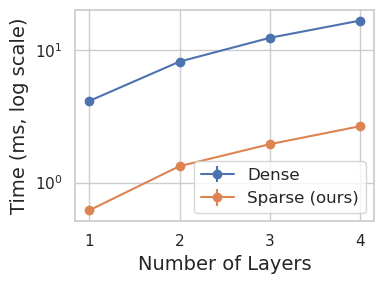

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

suptitlesize = 20
titlesize = 18
labelsize = 14
legendsize = 12
ticksize = 12

layers = [1, 2, 3, 4]
dense_time_mean = [4.129, 8.198, 12.406, 16.745]  # example mean times in ms
dense_time_std = [0.114, 0.108, 0.209, 0.271]     # example std deviations in ms
sparse_time_mean = [0.617, 1.332, 1.953, 2.669]  # example mean times in ms
sparse_time_std = [0.013, 0.081, 0.128, 0.110]     # example std deviations in ms

plt.figure(figsize=(4, 3))
sns.set(style="whitegrid")
plt.errorbar(layers, dense_time_mean, yerr=dense_time_std, label='Dense', fmt='-o')
plt.errorbar(layers, sparse_time_mean, yerr=sparse_time_std, label='Sparse (ours)', fmt='-o')
plt.yscale('log')
plt.xlabel('Number of Layers', fontsize=labelsize)
plt.ylabel('Time (ms, log scale)', fontsize=labelsize)
# plt.title(f'Time Analysis (Batch Size={args.batch_size}, In Features={args.in_features}, Out Features={args.out_features}, Samples={args.samples})')
plt.legend(fontsize=legendsize)
plt.tight_layout()
plt.savefig('./time_analysis_layers.pdf', bbox_inches='tight')
plt.show()